In [15]:
# SECTION 1: IMPORT & SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Import dari modules
from modules.nutrisi import hitung_kebutuhan
from modules.pso import hitung_penalti, hitung_fitness, SUBKATEGORI_ORDER

In [16]:
# SECTION 2: KONFIGURASI

# Data Pasien (gunakan data representatif)
JENIS_KELAMIN = "Wanita"   # "Pria" atau "Wanita"
BERAT_BADAN   = 47         # kg
TINGGI_BADAN  = 162        # cm
USIA          = 60         # tahun
AKTIVITAS     = "Sedang"   # "Istirahat", "Ringan", "Sedang", "Berat", "Sangat Berat"

# Path dataset
FILE_EXCEL = "resep.xlsx"

# Jumlah run per variasi
JUMLAH_RUN = 1

# Folder output grafik
FOLDER_GRAFIK = "hasil_tuning"
os.makedirs(FOLDER_GRAFIK, exist_ok=True)

print("KONFIGURASI PARAMETER TUNING PSO")
print(f"Pasien       : {JENIS_KELAMIN}, {USIA} tahun, {BERAT_BADAN}kg, {TINGGI_BADAN}cm")
print(f"Aktivitas    : {AKTIVITAS}")
print(f"Jumlah Run   : {JUMLAH_RUN} kali per variasi")
print(f"Output       : {FOLDER_GRAFIK}")

KONFIGURASI PARAMETER TUNING PSO
Pasien       : Wanita, 60 tahun, 47kg, 162cm
Aktivitas    : Sedang
Jumlah Run   : 1 kali per variasi
Output       : hasil_tuning


In [17]:
# SECTION 3: FUNGSI HELPER

def muat_dataset(file_excel):
    # Muat dataset dari Excel
    xls = pd.ExcelFile(file_excel)  # buka file Excel
    sarapan_df = pd.read_excel(xls, "Sarapan")  # ambil sheet Sarapan
    siang_df   = pd.read_excel(xls, "Makan Siang")  # ambil sheet Makan Siang
    malam_df   = pd.read_excel(xls, "Makan Malam")  # ambil sheet Makan Malam
    sayur_df   = pd.read_excel(xls, "Sayur")  # ambil sheet Sayur
    buah_df    = pd.read_excel(xls, "Buah")  # ambil sheet Buah
    nasi_df    = pd.read_excel(xls, "Nasi")  # ambil sheet Nasi
    
    return {
        "menu_sarapan":  sarapan_df,
        "sayur_sarapan": sayur_df,
        "nasi_sarapan":  nasi_df,
        "buah_sarapan":  buah_df,
        "buah_pagi":     buah_df.copy(),  # copy supaya tidak bentrok dengan yang lain
        "menu_siang":    siang_df,
        "sayur_siang":   sayur_df.copy(),
        "nasi_siang":    nasi_df.copy(),
        "buah_siang":    buah_df.copy(),
        "buah_sore":     buah_df.copy(),
        "menu_malam":    malam_df,
        "sayur_malam":   sayur_df.copy(),
        "nasi_malam":    nasi_df.copy(),
        "buah_malam":    buah_df.copy(),
    }


def pso_satu_run(dataset, target_sub, jumlah_partikel, iterasi_maks,
                 w_min=0.4, w_max=0.7, c1=1.0, c2=1.0):
    
    jumlah_resep    = len(dataset)  # jumlah menu dalam dataset
    x_min           = 0
    x_max           = jumlah_resep - 1  # batas index menu
    jumlah_partikel = min(jumlah_partikel, jumlah_resep)  # partikel tidak boleh lebih dari jumlah menu
    
    # Inisialisasi
    posisi_partikel    = np.round(x_min + np.random.random(jumlah_partikel) * (x_max - x_min)).astype(float)  # posisi awal random (index menu)
    kecepatan_partikel = np.zeros(jumlah_partikel, dtype=float)  # kecepatan awal = 0
    
    pbest_posisi  = posisi_partikel.copy()  # simpan posisi terbaik tiap partikel
    pbest_fitness = np.zeros(jumlah_partikel, dtype=float)  # simpan fitness terbaik
    
    for i in range(jumlah_partikel):
        indeks_menu      = int(round(np.clip(posisi_partikel[i], x_min, x_max)))  # pastikan index valid
        menu             = dataset.iloc[indeks_menu].to_dict()  # ambil menu berdasarkan index
        penalti          = hitung_penalti(menu, target_sub)  # hitung penalti
        pbest_fitness[i] = hitung_fitness(penalti)  # ubah penalti jadi fitness
    
    indeks_terbaik = int(np.argmax(pbest_fitness))  # cari partikel dengan fitness terbaik
    gbest_posisi   = pbest_posisi[indeks_terbaik]  # posisi terbaik global
    gbest_fitness  = pbest_fitness[indeks_terbaik]  # fitness terbaik global
    
    history_evaluasi = []  # simpan semua evaluasi selama PSO
    
    # Iterasi PSO
    for iterasi in range(iterasi_maks):
        w = w_min + (w_max - w_min) * (iterasi_maks - iterasi) / iterasi_maks  # inertia weight (semakin kecil seiring iterasi)
        
        for i in range(jumlah_partikel):
            r1 = np.random.random()  # random untuk pengaruh pbest
            r2 = np.random.random()  # random untuk pengaruh gbest
            
            kecepatan_baru = (
                w * kecepatan_partikel[i]  # pengaruh kecepatan sebelumnya
                + c1 * r1 * (pbest_posisi[i] - posisi_partikel[i])  # pengaruh pengalaman sendiri
                + c2 * r2 * (gbest_posisi - posisi_partikel[i])  # pengaruh global terbaik
            )
            kecepatan_partikel[i] = kecepatan_baru
            
            posisi_partikel[i] = np.clip(
                round(posisi_partikel[i] + kecepatan_baru),  # update posisi
                x_min, x_max  # tetap dalam batas index
            )
            
            indeks_menu  = int(round(posisi_partikel[i]))
            menu         = dataset.iloc[indeks_menu].to_dict()
            penalti_baru = hitung_penalti(menu, target_sub)  # evaluasi menu baru
            fitness_baru = hitung_fitness(penalti_baru)
            
            history_evaluasi.append((indeks_menu, fitness_baru))  # simpan hasil evaluasi
            
            if fitness_baru > pbest_fitness[i]:  # update pbest jika lebih baik
                pbest_fitness[i] = fitness_baru
                pbest_posisi[i]  = posisi_partikel[i]
        
        for i in range(jumlah_partikel):
            if pbest_fitness[i] > gbest_fitness:  # update global best
                gbest_fitness = pbest_fitness[i]
                gbest_posisi  = pbest_posisi[i]
    
    # Ambil fitness tertinggi per menu dari history
    fitness_per_menu = {}
    for indeks_menu, fitness_val in history_evaluasi:
        if indeks_menu not in fitness_per_menu:
            fitness_per_menu[indeks_menu] = fitness_val
        else:
            fitness_per_menu[indeks_menu] = max(fitness_per_menu[indeks_menu], fitness_val)  # ambil yang terbaik jika muncul lagi
    
    if not fitness_per_menu:
        return None, None  # kalau tidak ada hasil
    
    # Hitung rata-rata penalti dan fitness dari semua menu yang dievaluasi PSO
    semua_penalti = []
    semua_fitness = []
    for indeks_menu, fitness_val in fitness_per_menu.items():
        menu    = dataset.iloc[indeks_menu].to_dict()
        penalti = hitung_penalti(menu, target_sub)
        semua_penalti.append(penalti)
        semua_fitness.append(fitness_val)
    
    return np.mean(semua_penalti), np.mean(semua_fitness)  # hasil akhir = rata-rata


def uji_satu_variasi(dataset_per_sub, target_subkategori,
                     jumlah_partikel_per_sub, iterasi_maks_per_sub,
                     w_min, w_max, label_variasi):
    # Uji satu variasi parameter untuk semua subkategori
    
    print(f"\n  Variasi: {label_variasi}")
    print(f"  {'Subkategori':<18} {'Rata Penalti':>14} {'Rata Fitness':>14}")
    print(f"  {'-'*48}")
    
    hasil_per_sub = {}
    
    for nama_sub in SUBKATEGORI_ORDER:  # loop semua subkategori
        dataset      = dataset_per_sub[nama_sub]
        target_sub   = target_subkategori[nama_sub]
        iterasi_maks = iterasi_maks_per_sub[nama_sub]
        n_partikel   = jumlah_partikel_per_sub[nama_sub]
        
        daftar_penalti = []
        daftar_fitness = []
        
        for _ in range(JUMLAH_RUN):  # jalankan PSO berkali-kali (biar stabil)
            penalti, fitness = pso_satu_run(
                dataset, target_sub,
                jumlah_partikel=n_partikel,
                iterasi_maks=iterasi_maks,
                w_min=w_min, w_max=w_max
            )
            if penalti is not None:
                daftar_penalti.append(penalti)  # kumpulin hasil tiap run
                daftar_fitness.append(fitness)
        
        rata_penalti = np.mean(daftar_penalti) if daftar_penalti else 0.0  # rata-rata penalti
        rata_fitness = np.mean(daftar_fitness) if daftar_fitness else 0.0  # rata-rata fitness
        
        hasil_per_sub[nama_sub] = {
            "rata_penalti": rata_penalti,
            "rata_fitness": rata_fitness,
        }
        
        print(f"  {nama_sub:<18} {rata_penalti:>14.4f} {rata_fitness:>14.4f}")
    
    rata_penalti_global = np.mean([v["rata_penalti"] for v in hasil_per_sub.values()])  # rata-rata semua subkategori
    rata_fitness_global = np.mean([v["rata_fitness"] for v in hasil_per_sub.values()])
    
    print(f"  {'-'*48}")
    print(f"  {'RATA-RATA GLOBAL':<18} {rata_penalti_global:>14.4f} {rata_fitness_global:>14.4f}")
    
    return hasil_per_sub, rata_penalti_global, rata_fitness_global


def buat_grafik(label_x, nilai_x, rata_penalti_list, rata_fitness_list,
                judul, nama_file):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # buat 2 grafik (penalti & fitness)
    fig.suptitle(judul, fontsize=13, fontweight="bold")
    
    # Grafik rata-rata penalti
    ax1.plot(nilai_x, rata_penalti_list, marker="o", color="steelblue", linewidth=2)  # plot penalti
    for x, y in zip(nilai_x, rata_penalti_list):
        ax1.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)  # kasih label angka
    ax1.set_xlabel(label_x)
    ax1.set_ylabel("Rata-Rata Penalti Rank-1")
    ax1.set_title("Rata-Rata Penalti")
    ax1.set_xticks(nilai_x)
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    min_penalti = min(rata_penalti_list)
    max_penalti = max(rata_penalti_list)
    margin_p = (max_penalti - min_penalti) * 0.5
    ax1.set_ylim(min_penalti - margin_p, max_penalti + margin_p)
    
    # Grafik rata-rata fitness
    ax2.plot(nilai_x, rata_fitness_list, marker="o", color="darkorange", linewidth=2)  # plot fitness
    for x, y in zip(nilai_x, rata_fitness_list):
        ax2.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)
    ax2.set_xlabel(label_x)
    ax2.set_ylabel("Rata-Rata Fitness Rank-1")
    ax2.set_title("Rata-Rata Fitness")
    ax2.set_xticks(nilai_x)
    ax2.grid(True, linestyle="--", alpha=0.5)
    
    min_fitness = min(rata_fitness_list)
    max_fitness = max(rata_fitness_list)
    margin_f = (max_fitness - min_fitness) * 0.5
    ax2.set_ylim(min_fitness - margin_f, max_fitness + margin_f)
    
    plt.tight_layout()
    
    path_file = os.path.join(FOLDER_GRAFIK, nama_file)
    plt.savefig(path_file, dpi=150, bbox_inches="tight")  # simpan grafik ke file
    print(f"\nGrafik disimpan: {path_file}")
    
    plt.show()
    plt.close()  # tutup

In [18]:
# SECTION 4: PERSIAPAN DATA

# Hitung kebutuhan nutrisi pasien
nutrisi_harian, per_waktu, target_subkategori = hitung_kebutuhan(
    jk=JENIS_KELAMIN,
    bb=BERAT_BADAN,
    tb=TINGGI_BADAN,
    usia=USIA,
    aktivitas=AKTIVITAS
)

# Muat dataset
dataset_per_sub = muat_dataset(FILE_EXCEL)
iterasi_dasar   = {s: len(dataset_per_sub[s]) for s in SUBKATEGORI_ORDER}

print("DATA SIAP")
print(f"Kebutuhan Kalori Harian: {nutrisi_harian['kalori'][0]:.1f} - {nutrisi_harian['kalori'][1]:.1f} kkal")
print(f"Jumlah Subkategori     : {len(SUBKATEGORI_ORDER)}")
print("\nJumlah menu per subkategori:")
for nama_sub in SUBKATEGORI_ORDER:
    print(f"  {nama_sub:<18}: {len(dataset_per_sub[nama_sub]):3d} menu (iterasi dasar: {iterasi_dasar[nama_sub]})")
print("=" * 60)

DATA SIAP
Kebutuhan Kalori Harian: 1849.8 - 2003.9 kkal
Jumlah Subkategori     : 14

Jumlah menu per subkategori:
  menu_sarapan      :  35 menu (iterasi dasar: 35)
  sayur_sarapan     :  55 menu (iterasi dasar: 55)
  nasi_sarapan      :   3 menu (iterasi dasar: 3)
  buah_sarapan      : 258 menu (iterasi dasar: 258)
  buah_pagi         : 258 menu (iterasi dasar: 258)
  menu_siang        :  35 menu (iterasi dasar: 35)
  sayur_siang       :  55 menu (iterasi dasar: 55)
  nasi_siang        :   3 menu (iterasi dasar: 3)
  buah_siang        : 258 menu (iterasi dasar: 258)
  buah_sore         : 258 menu (iterasi dasar: 258)
  menu_malam        :  35 menu (iterasi dasar: 35)
  sayur_malam       :  55 menu (iterasi dasar: 55)
  nasi_malam        :   3 menu (iterasi dasar: 3)
  buah_malam        : 258 menu (iterasi dasar: 258)


PENGUJIAN 1: JUMLAH ITERASI

  Variasi: iterasi=1x jumlah_resep | partikel=jumlah_resep | w=[0.4, 0.9]
  Subkategori          Rata Penalti   Rata Fitness
  ------------------------------------------------
  menu_sarapan              15.1891       152.4633
  sayur_sarapan              4.6642       369.6027
  nasi_sarapan               1.0022       997.8219
  buah_sarapan               4.4357       321.3983
  buah_pagi                  3.0671       343.7355
  menu_siang                10.5000       159.4644
  sayur_siang                2.9052       584.9443
  nasi_siang                 2.1758       466.2927
  buah_siang                 3.2916       367.3726
  buah_sore                  3.4124       304.9920
  menu_malam                14.6225       106.3327
  sayur_malam                3.6111       495.7644
  nasi_malam                 2.2153       451.4197
  buah_malam                 3.6744       355.0940
  ------------------------------------------------
  RATA-RATA GLOBAL           5

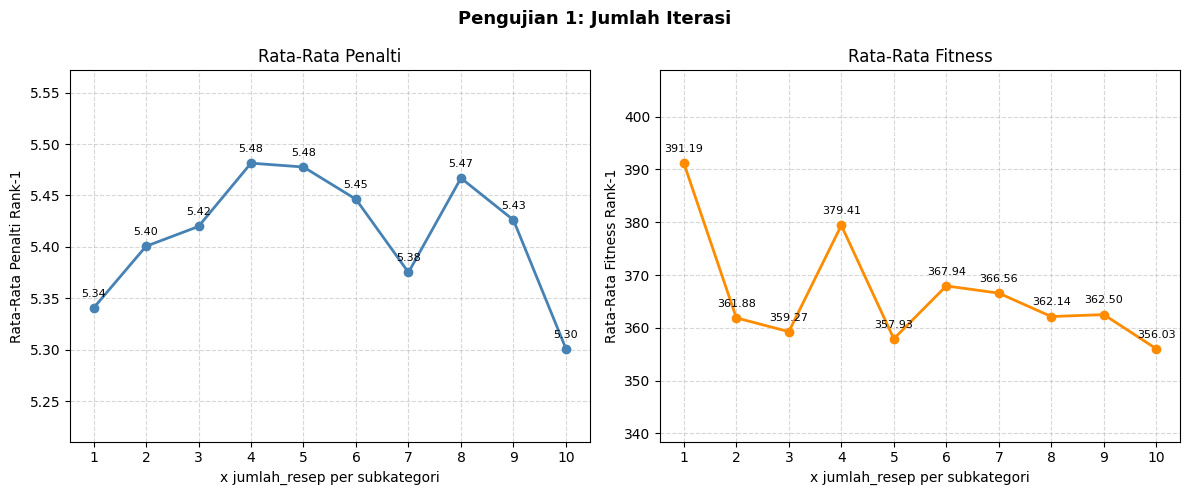

In [19]:
# SECTION 5: PENGUJIAN 1 - JUMLAH ITERASI

print("PENGUJIAN 1: JUMLAH ITERASI")

variasi_mult_iterasi = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
rata_penalti_iterasi = []
rata_fitness_iterasi = []

for mult in variasi_mult_iterasi:
    iterasi_var  = {s: iterasi_dasar[s] * mult for s in SUBKATEGORI_ORDER}
    partikel_var = {s: len(dataset_per_sub[s]) for s in SUBKATEGORI_ORDER}

    _, rata_p, rata_f = uji_satu_variasi(
        dataset_per_sub, target_subkategori,
        jumlah_partikel_per_sub=partikel_var,
        iterasi_maks_per_sub=iterasi_var,
        w_min=0.4, w_max=0.9,
        label_variasi=f"iterasi={mult}x jumlah_resep | partikel=jumlah_resep | w=[0.4, 0.9]"
    )
    rata_penalti_iterasi.append(rata_p)
    rata_fitness_iterasi.append(rata_f)

print(f"\nHasil pengujian iterasi:")
print(f"  {'Multiplier':<12} {'Rata Penalti':>14} {'Rata Fitness':>14} {'Perubahan':>12}")
print(f"  {'-'*54}")
for i, (mult, rp, rf) in enumerate(zip(variasi_mult_iterasi, rata_penalti_iterasi, rata_fitness_iterasi)):
    if i == 0:
        perubahan = "-"
    else:
        perubahan = f"{((rf - rata_fitness_iterasi[i-1]) / rata_fitness_iterasi[i-1]) * 100:+.2f}%"
    print(f"  {mult}x            {rp:>14.4f} {rf:>14.4f} {perubahan:>12}")

print(f"Pakai 1x jumlah_resep (tanpa perkalian)")

mult_iterasi_terbaik = 1
print(f"Iterasi yang dipakai: {mult_iterasi_terbaik}x jumlah_resep per subkategori")

buat_grafik(
    label_x="x jumlah_resep per subkategori",
    nilai_x=variasi_mult_iterasi,
    rata_penalti_list=rata_penalti_iterasi,
    rata_fitness_list=rata_fitness_iterasi,
    judul="Pengujian 1: Jumlah Iterasi",
    nama_file="1_pengujian_iterasi.png"
)

PENGUJIAN 2: JUMLAH PARTIKEL

  Variasi: partikel=1x jumlah_resep | iterasi=1x | w=[0.4, 0.9]
  Subkategori          Rata Penalti   Rata Fitness
  ------------------------------------------------
  menu_sarapan              15.2712       154.9521
  sayur_sarapan              4.6610       365.5379
  nasi_sarapan               2.1094       474.0722
  buah_sarapan               4.4202       322.7981
  buah_pagi                  3.0671       343.7355
  menu_siang                10.8263       152.0001
  sayur_siang                2.8238       616.6444
  nasi_siang                 2.1758       466.2927
  buah_siang                 3.3097       364.8260
  buah_sore                  3.4124       304.9920
  menu_malam                14.6225       106.3327
  sayur_malam                3.4281       505.4657
  nasi_malam                 1.8508       560.6471
  buah_malam                 3.6817       354.3763
  ------------------------------------------------
  RATA-RATA GLOBAL           5.4043    

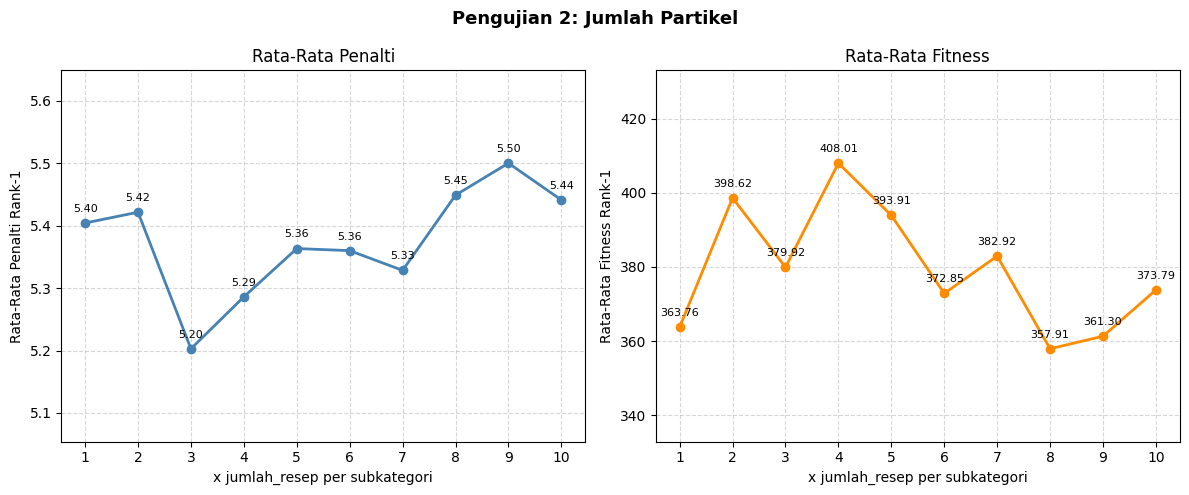

In [20]:
# SECTION 6: PENGUJIAN 2 - JUMLAH PARTIKEL

print("PENGUJIAN 2: JUMLAH PARTIKEL")

iterasi_terbaik_per_sub = {s: iterasi_dasar[s] * mult_iterasi_terbaik for s in SUBKATEGORI_ORDER}

variasi_mult_partikel = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
rata_penalti_partikel = []
rata_fitness_partikel = []

for mult in variasi_mult_partikel:
    partikel_var = {s: int(len(dataset_per_sub[s]) * mult) for s in SUBKATEGORI_ORDER}

    _, rata_p, rata_f = uji_satu_variasi(
        dataset_per_sub, target_subkategori,
        jumlah_partikel_per_sub=partikel_var,
        iterasi_maks_per_sub=iterasi_terbaik_per_sub,
        w_min=0.4, w_max=0.9,
        label_variasi=f"partikel={mult}x jumlah_resep | iterasi={mult_iterasi_terbaik}x | w=[0.4, 0.9]"
    )
    rata_penalti_partikel.append(rata_p)
    rata_fitness_partikel.append(rata_f)

print(f"\nHasil pengujian partikel:")
print(f"  {'Multiplier':<12} {'Rata Penalti':>14} {'Rata Fitness':>14} {'Perubahan':>12}")
print(f"  {'-'*54}")
for i, (mult, rp, rf) in enumerate(zip(variasi_mult_partikel, rata_penalti_partikel, rata_fitness_partikel)):
    if i == 0:
        perubahan = "-"
    else:
        perubahan = f"{((rf - rata_fitness_partikel[i-1]) / rata_fitness_partikel[i-1]) * 100:+.2f}%"
    print(f"  {mult}x            {rp:>14.4f} {rf:>14.4f} {perubahan:>12}")

print(f"Pakai 1x jumlah_resep per subkategori (tanpa perkalian)")

mult_partikel_terbaik = 1
print(f"Partikel yang dipakai: {mult_partikel_terbaik}x jumlah_resep per subkategori")

buat_grafik(
    label_x="x jumlah_resep per subkategori",
    nilai_x=variasi_mult_partikel,
    rata_penalti_list=rata_penalti_partikel,
    rata_fitness_list=rata_fitness_partikel,
    judul="Pengujian 2: Jumlah Partikel",
    nama_file="2_pengujian_partikel.png"
)

PENGUJIAN 3: NILAI w_max

  Variasi: w_min=0.4 | w_max=0.5 | iterasi=1x | partikel=5x
  Subkategori          Rata Penalti   Rata Fitness
  ------------------------------------------------
  menu_sarapan              13.7099       166.2890
  sayur_sarapan              4.7164       366.4233
  nasi_sarapan               1.5558       735.9471
  buah_sarapan               4.5356       321.4363
  buah_pagi                  3.0730       343.1388
  menu_siang                11.4523       151.5290
  sayur_siang                2.9696       628.1002
  nasi_siang                 2.1758       466.2927
  buah_siang                 3.3982       363.4504
  buah_sore                  3.4250       304.6604
  menu_malam                14.4558       102.5044
  sayur_malam                3.7431       489.1929
  nasi_malam                 2.2153       451.4197
  buah_malam                 3.8333       350.4243
  ------------------------------------------------
  RATA-RATA GLOBAL           5.3757       374.3

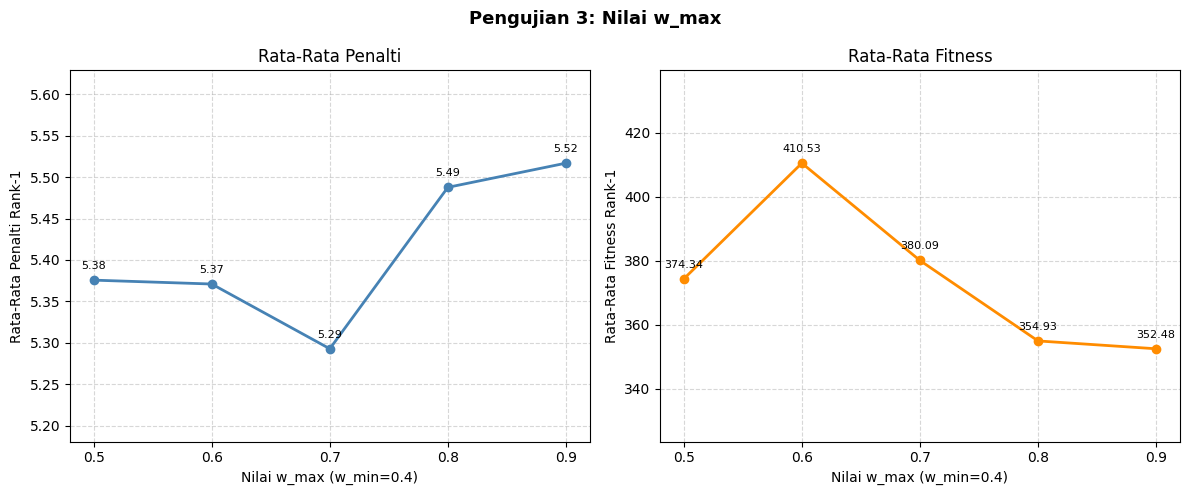

In [21]:
# SECTION 7: PENGUJIAN 3 - NILAI w_max

print("PENGUJIAN 3: NILAI w_max")

partikel_terbaik_per_sub = {s: int(len(dataset_per_sub[s]) * 5) for s in SUBKATEGORI_ORDER}

variasi_wmax      = [0.5, 0.6, 0.7, 0.8, 0.9]
label_w           = [f"0.4;{wmax}" for wmax in variasi_wmax]
rata_penalti_wmax = []
rata_fitness_wmax = []

for wmax in variasi_wmax:
    _, rata_p, rata_f = uji_satu_variasi(
        dataset_per_sub, target_subkategori,
        jumlah_partikel_per_sub=partikel_terbaik_per_sub,
        iterasi_maks_per_sub=iterasi_terbaik_per_sub,
        w_min=0.4, w_max=wmax,
        label_variasi=f"w_min=0.4 | w_max={wmax} | iterasi={mult_iterasi_terbaik}x | partikel=5x"
    )
    rata_penalti_wmax.append(rata_p)
    rata_fitness_wmax.append(rata_f)

print(f"\nHasil pengujian w_max:")
print(f"  {'w_min;w_max':<12} {'Rata Penalti':>14} {'Rata Fitness':>14} {'Perubahan':>12}")
print(f"  {'-'*54}")
for i, (lbl, rp, rf) in enumerate(zip(label_w, rata_penalti_wmax, rata_fitness_wmax)):
    if i == 0:
        perubahan = "-"
    else:
        perubahan = f"{((rf - rata_fitness_wmax[i-1]) / rata_fitness_wmax[i-1]) * 100:+.2f}%"
    print(f"  {lbl:<12} {rp:>14.4f} {rf:>14.4f} {perubahan:>12}")

idx_terbaik_wmax = int(np.argmax(rata_fitness_wmax))
wmax_terbaik     = variasi_wmax[idx_terbaik_wmax]
print(f"\nw_max terbaik: {wmax_terbaik} (fitness tertinggi)")
print(f"w yang dipakai: w_min=0.4 | w_max={wmax_terbaik}")

buat_grafik(
    label_x="Nilai w_max (w_min=0.4)",
    nilai_x=variasi_wmax,
    rata_penalti_list=rata_penalti_wmax,
    rata_fitness_list=rata_fitness_wmax,
    judul="Pengujian 3: Nilai w_max",
    nama_file="3_pengujian_wmax.png"
)